# Hybrid Deep GP models: combining GP and Neural Network layers

In this notebook we show how to combine `gpflux.layers.GPLayer` layers with plain Keras neural network layers. This allows one to build hybrid deep GP models. Compared to the other tutorials, we are also going to use Keras's `Sequential` model to build our hierarchical model and use a `gpflux.losses.LikelihoodLoss` instead of a `gpflux.layers.LikelihoodLayer`.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import gpflow
import gpflux

from gpflow.config import default_float

2024-01-08 14:39:34.430581: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-01-08 14:39:34.461086: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-01-08 14:39:34.462140: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2024-01-08 14:39:35.132442: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Load Snelson dataset

We use a simple one-dimensional dataset to allow for easy plotting. To help training we normalize the input features.

In [2]:
d = np.load("../../tests/snelson1d.npz")
X, Y = data = d["X"], d["Y"]
X = (X - X.mean()) / X.std()
num_data, input_dim = X.shape

## Initialize the GP Layer

As per usual we create a one-dimensional `gpflux.layers.GPLayer` with a simple `SquaredExponential` kernel and `InducingPoints` inducing variable:

In [3]:
num_data = len(X)
num_inducing = 10
output_dim = Y.shape[1]

kernel = gpflow.kernels.SquaredExponential()
inducing_variable = gpflow.inducing_variables.InducingPoints(
    np.linspace(X.min(), X.max(), num_inducing).reshape(-1, 1)
)
gp_layer = gpflux.layers.GPLayer(
    kernel, inducing_variable, num_data=num_data, num_latent_gps=output_dim
)

/home/runner/work/GPflux/GPflux/gpflux/layers/gp_layer.py:175: UserWarning: Beware, no mean function was specified in the construction of the `GPLayer` so the default `gpflow.mean_functions.Identity` is being used. This mean function will only work if the input dimensionality matches the number of latent Gaussian processes in the layer.
  warnings.warn(
/home/runner/work/GPflux/GPflux/gpflux/layers/gp_layer.py:198: UserWarning: Could not verify the compatibility of the `kernel`, `inducing_variable` and `mean_function`. We advise using `gpflux.helpers.construct_*` to create compatible kernels and inducing variables. As `num_latent_gps=1` has been specified explicitly, this will be used to create the `q_mu` and `q_sqrt` parameters.
  warnings.warn(


## Sequential Keras model with GP and Neural net layers

We construct a model that consists of three `tf.keras.layers.Dense` layers and a GP. The first two Dense layers are configured to have 100 units and use a ReLU non-linearity. The last neural network layers reduces the dimension to one and does not utilise a non-linearity. We can interpret these three neural network layers as performing non-linear feature warping. The final layer in the model is the GP we defined above.

In [4]:
likelihood = gpflow.likelihoods.Gaussian(0.1)

# So that Keras can track the likelihood variance, we need to provide the likelihood as part of a "dummy" layer:
likelihood_container = gpflux.layers.TrackableLayer()
likelihood_container.likelihood = likelihood

model = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(100, activation="relu"),
        tf.keras.layers.Dense(100, activation="relu"),
        tf.keras.layers.Dense(1, activation="linear"),
        gp_layer,
        likelihood_container,  # no-op, for discovering trainable likelihood parameters
    ]
)
loss = gpflux.losses.LikelihoodLoss(likelihood)

/tmp/ipykernel_3187/712807007.py:4: DeprecationWarning: Call to deprecated class TrackableLayer. (GPflux's `TrackableLayer` was prior to TF2.5 used to collect GPflow variables in subclassed layers. As of TF 2.5, `tf.Module` supports this natively and there is no need for `TrackableLayer` anymore. It will be removed in GPflux version `1.0.0`.)
  likelihood_container = gpflux.layers.TrackableLayer()


We compile our model by specifying the loss and the optimizer to use. After this is done, we fit the data and plot the trajectory of the loss:

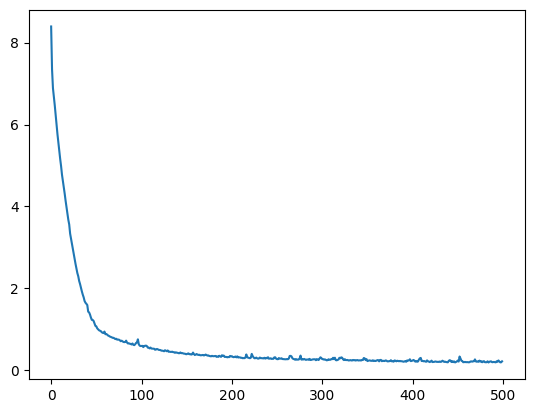

In [5]:
model.compile(loss=loss, optimizer="adam")
hist = model.fit(X, Y, epochs=500, verbose=0)
plt.plot(hist.history["loss"])

We can now inspect the final model by plotting its predictions. Note that `model(X_test)` now returns the output of the final `GPLayer` and *not* a `LikelihoodLayer`. The output of a `GPLayer` is a TFP distribution with a `mean()` and `variance()`.

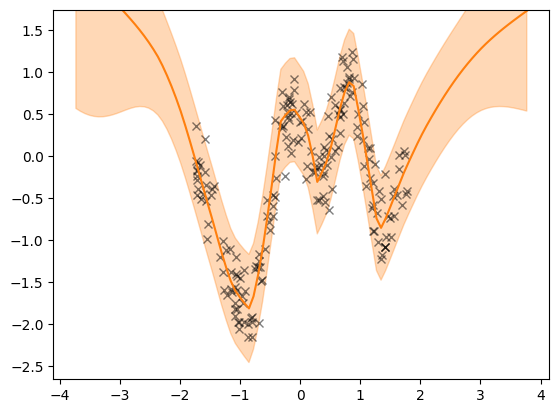

In [6]:
def plot(model, X, Y, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    x_margin = 2.0
    N_test = 100
    X_test = np.linspace(X.min() - x_margin, X.max() + x_margin, N_test).reshape(-1, 1)
    f_distribution = model(X_test)

    mean = f_distribution.mean().numpy().squeeze()
    var = f_distribution.variance().numpy().squeeze() + model.layers[-1].likelihood.variance.numpy()
    X_test = X_test.squeeze()
    lower = mean - 2 * np.sqrt(var)
    upper = mean + 2 * np.sqrt(var)

    ax.set_ylim(Y.min() - 0.5, Y.max() + 0.5)
    ax.plot(X, Y, "kx", alpha=0.5)
    ax.plot(X_test, mean, "C1")

    ax.fill_between(X_test, lower, upper, color="C1", alpha=0.3)


plot(model, X, Y)

In [7]:
gpflow.utilities.print_summary(model, fmt="notebook")

name,class,transform,prior,trainable,shape,dtype,value
Sequential._self_tracked_trackables[1]._trainable_weights[0] Sequential._self_tracked_trackables[1].kernel,UnliftedInitializerVariable,,,True,"(1, 100)",float32,"[[0.00353, 0.10744, -0.11243..."
Sequential._self_tracked_trackables[1]._trainable_weights[1] Sequential._self_tracked_trackables[1].bias,UnliftedInitializerVariable,,,True,"(100,)",float32,"[-6.7300e-03, -1.0082e-01, 2.9180e-02..."
Sequential._self_tracked_trackables[2]._trainable_weights[0] Sequential._self_tracked_trackables[2].kernel,UnliftedInitializerVariable,,,True,"(100, 100)",float32,"[[-0.05602, 0.16399, 0.09959..."
Sequential._self_tracked_trackables[2]._trainable_weights[1] Sequential._self_tracked_trackables[2].bias,UnliftedInitializerVariable,,,True,"(100,)",float32,"[0.06823, 0.06136, 0.06485..."
Sequential._self_tracked_trackables[3]._trainable_weights[0] Sequential._self_tracked_trackables[3].kernel,UnliftedInitializerVariable,,,True,"(100, 1)",float32,[[0.51156...
Sequential._self_tracked_trackables[3]._trainable_weights[1] Sequential._self_tracked_trackables[3].bias,UnliftedInitializerVariable,,,True,"(1,)",float32,[-0.10312]
Sequential._self_tracked_trackables[4]._trainable_weights[0],ResourceVariable,,,True,"(10, 1)",float64,[[-0.69233...
Sequential._self_tracked_trackables[4]._trainable_weights[1],ResourceVariable,,,True,"(1, 55)",float64,"[[0.91457, 0.24804, -0.23825..."
Sequential._self_tracked_trackables[4]._metrics[0]._non_trainable_weights[0] Sequential._self_tracked_trackables[4]._metrics[0].total,UnliftedInitializerVariable,,,False,(),float64,0.26117
Sequential._self_tracked_trackables[4]._metrics[0]._non_trainable_weights[1] Sequential._self_tracked_trackables[4]._metrics[0].count,UnliftedInitializerVariable,,,False,(),float64,8.0
